<a href="https://colab.research.google.com/github/UTD2026/Mixed_Dataset_Testing_STA/blob/main/TTL_StressTest_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TTL label-free pipeline — full stress test & "distance from the full idea"

This notebook is the diagnostic we agreed to run **before** committing engineering effort: it
measures which of the addressed issues actually bind, and by how much, so the fixes get
prioritised by evidence instead of by theory. It follows the structure of
`LabelFree_Router_Test.ipynb` (clone → Colab-compat patch → run repo scripts → analyse) but
expands the single-issue tail (does a label-free router exist?) into a suite covering every
issue we raised.

**What it tests (one section each):**

| # | Issue | Core question | Runs on |
|---|---|---|---|
| D1 | Distribution shift / headroom (kill-switch) | Does this domain even have oracle TTL headroom? | committed artifacts |
| D2 | **Labelling** | Does *any* label-free signal route as well as gold-leaking `out_ce`? | committed + GPU (CMP) |
| D3 | Distribution shift transfer | Does a router calibrated on domain A hold on domain B? | committed + GPU |
| D4 | Self-consistency encodes its own distribution | Does the verifier saturate into the votes with scale? | committed crossover txts |
| D5 | **Alter the adapter** | Does anchoring cut collateral forgetting / unrouted collapse? | GPU arm (committed motivates) |
| D6 | Cost-accounting honesty | Full-denominator Pareto once train + pseudo-label gen are counted | committed |
| D7 | Unification tension | Do selection & routing signals fail together if unified? | committed |
| D8 | Offline vs online routing | Streaming-quantile error vs offline quantile | committed |
| D9 | Contamination | Is the "shifted" bench actually novel? | procedure (no compute) |

**Design:** every diagnostic runs on the repo's **committed per-item artifacts** (real
`base_ok`/`adapted_ok`/`out_ce`/`q_ce`/`mc_margin`/`mc_top_p`/`admission_score` for n=1000 across
logiqa / medicine / geography and two scales). Set `RUN_GPU=True` (default) to additionally
produce the signals that need a live model — the cross-model **CMP** signal, the **anchored**
adapter, and true **cross-domain** transfer. With `RUN_GPU=False` the whole scorecard still
completes on committed data, so you can develop it anywhere and only spend GPU on the rows that
need it. It ends in a consolidated **scorecard + distance-from-full-idea** readout.

## 0 · Runtime knobs

In [5]:
# ---- repo / runtime knobs ----
REPO_URL   = "https://github.com/UTD2026/rishabh-tlm.git"
WORK       = "/content/tlm_stress"                                   # change if not on Colab
LOCAL_REPO_ZIP = "/content/rishabh-tlm-main.zip"                     # clone fallback (upload the repo zip)
GITHUB_TOKEN_ENV = "GITHUB_TOKEN"                                    # optional, for private clone

MODEL      = "Qwen/Qwen3.5-0.8B"      # bump to -2B to rerun the GPU arms at scale
DATASETS   = ["logiqa", "medicine", "geography"]                     # geography = honest low-headroom case
N_BY_DATASET = {"logiqa": 1000, "medicine": 1000, "geography": 225}

RUN_GPU    = True     # False -> scorecard still completes on committed artifacts only
K_SAMPLES  = 8        # self-consistency samples used for label-free pseudo-labels (D6 cost)
ANCHOR_LAMBDA = 0.1   # D5 adapter-anchoring strength (0 = vanilla specialist)
print({"work": WORK, "model": MODEL, "datasets": DATASETS, "RUN_GPU": RUN_GPU})

{'work': '/content/tlm_stress', 'model': 'Qwen/Qwen3.5-0.8B', 'datasets': ['logiqa', 'medicine', 'geography'], 'RUN_GPU': True}


## 1 · Environment setup (Colab GPU box)

Written for a CUDA runtime. Qwen3.5 needs recent Transformers; Colab images often carry
`torchaudio`/`torchvision`/`torchao` that are *present-but-CUDA-mismatched*, which git-main
`transformers`/`peft` treat as a hard error — so we remove the unused ones. Skip the install
cell if your image already has these. This mirrors the reference notebook's proven setup.

In [6]:
import os, sys, subprocess
from pathlib import Path
Path(WORK).mkdir(parents=True, exist_ok=True); os.chdir(WORK)

INSTALL_DEPS = RUN_GPU  # analysis-only runs need just numpy/pandas/matplotlib (usually preinstalled)
def pip(*a):
    print("RUN: pip", *a); subprocess.check_call([sys.executable, "-m", "pip", *a])

if INSTALL_DEPS:
    pip("install", "-U", "peft", "accelerate", "scipy", "sympy", "ninja", "huggingface_hub")
    if "Qwen3.5" in MODEL:
        pip("install", "-U", "transformers[serving] @ git+https://github.com/huggingface/transformers.git@main")
    else:
        pip("install", "-U", "transformers")
    # remove unused, CUDA-mismatched optional extensions that crash the text-only path
    for pkg in ["torchaudio", "torchvision", "torchao"]:
        try: pip("uninstall", "-y", pkg)
        except Exception as e: print(f"(uninstall {pkg} skipped: {e!r})")
    for m in list(sys.modules):
        if m.startswith(("torchaudio","torchvision","torchao","transformers","peft")): del sys.modules[m]

# these three are all the analysis needs
import numpy as np, pandas as pd, matplotlib.pyplot as plt
print("analysis stack ready")

RUN: pip install -U peft accelerate scipy sympy ninja huggingface_hub
RUN: pip install -U transformers[serving] @ git+https://github.com/huggingface/transformers.git@main
RUN: pip uninstall -y torchaudio
RUN: pip uninstall -y torchvision
RUN: pip uninstall -y torchao
analysis stack ready


## 2 · Clone / locate the repo (token + zip fallback)

The committed artifacts under `results/` are what the offline diagnostics read, so we need the
repo present regardless of `RUN_GPU`.

In [7]:
import os, subprocess, shutil, zipfile
from pathlib import Path

repo_dir = Path(WORK) / "rishabh-tlm"

def _clone(url):
    tok = os.environ.get(GITHUB_TOKEN_ENV, "").strip()
    u = url.replace("https://", f"https://{tok}@", 1) if (tok and url.startswith("https://github.com/")) else url
    return subprocess.run(["git", "clone", "--depth", "1", u, str(repo_dir)], text=True,
                          stdout=subprocess.PIPE, stderr=subprocess.PIPE)

def _extract_zip(zp: Path):
    """Extract a repo zip into repo_dir, accepting root-level or nested-one-level layouts."""
    zp = Path(zp).expanduser()
    if not zp.exists():
        raise FileNotFoundError(f"zip not found: {zp}")
    print("extracting:", zp)
    tmp = Path(WORK) / "_zip"; shutil.rmtree(tmp, ignore_errors=True); tmp.mkdir(parents=True)
    with zipfile.ZipFile(zp) as zf:
        zf.extractall(tmp)
    # the repo root is the dir that contains both cuda_ttl/ and results/
    if (tmp / "cuda_ttl").exists() and (tmp / "results").exists():
        cand = tmp
    else:
        cand = next((p for p in tmp.rglob("*")
                     if p.is_dir() and (p / "cuda_ttl").exists() and (p / "results").exists()), None)
    if cand is None:
        raise RuntimeError("repo root (a dir with cuda_ttl/ and results/) not found in zip")
    shutil.rmtree(repo_dir, ignore_errors=True)
    shutil.move(str(cand), str(repo_dir))

if not repo_dir.exists():
    r = _clone(REPO_URL)
    if r.returncode != 0:
        print("clone failed (repo is private / no token).")
        zp = Path(LOCAL_REPO_ZIP)
        if zp.exists():
            print("found zip at LOCAL_REPO_ZIP:", zp)
            _extract_zip(zp)
        else:
            # no clone, no pre-staged zip -> prompt an upload right here
            uploaded = None
            try:
                from google.colab import files  # Colab runtime
                print("Upload the repo zip (e.g. rishabh-tlm-main.zip) when the picker appears...")
                up = files.upload()  # opens the file picker
                # pick the first .zip that was uploaded
                names = [n for n in up if n.lower().endswith(".zip")] or list(up)
                if not names:
                    raise RuntimeError("no file uploaded")
                uploaded = Path("/content") / names[0]
                # files.upload() writes into the cwd; make sure we point at the real path
                if not uploaded.exists():
                    uploaded = Path(names[0]).resolve()
            except ImportError:
                # non-Colab runtime: fall back to a manual path prompt
                p = input("Not on Colab. Enter the full path to the repo zip: ").strip().strip('"')
                uploaded = Path(p)
            _extract_zip(uploaded)

os.chdir(repo_dir)
REPO_DIR = Path.cwd()
assert (REPO_DIR / "results").exists(), "results/ not found — committed artifacts missing"
print("repo:", REPO_DIR, "| results/ present:", (REPO_DIR / "results").exists())

repo: /content/tlm_stress/rishabh-tlm | results/ present: True


## 3 · Load the committed per-item artifacts (real data, no GPU)

Every routing/grid eval the team shipped stores per-item `base_ok`, `adapted_ok`, and the
feature signals. We flatten them into one long table keyed by (dataset, model, pool). This is
the substrate for D1–D8.

In [8]:
import json, glob, os
import numpy as np, pandas as pd

def _load_grid(path, model, pool):
    d = json.load(open(path)); out=[]
    for it in d["items"]:
        out.append(dict(dataset=d["dataset"], model=model, pool=pool, idx=it["idx"],
                        base_ok=bool(it["base_ok"]), adapted_ok=bool(it["adapted_ok"]),
                        out_ce=it.get("out_ce"), q_ce=it.get("q_ce"),
                        mc_margin=it.get("mc_margin"), mc_top_p=it.get("mc_top_p"),
                        admission_score=it.get("admission_score")))
    return d, out

recs, refs_by = [], {}
# sbar_phase1: medicine 0.8b/2b random pools (per-item)
for f in glob.glob(str(REPO_DIR/"results/sbar_phase1_2026-07-09/*grid_random*.json")):
    b=os.path.basename(f); model="0.8b" if b.startswith("08b") else "2b"
    pool="random"+"".join(c for c in b.split("random")[1] if c.isdigit())
    d,r=_load_grid(f,model,pool); recs+=r; refs_by[(d["dataset"],model,pool)]=d["refs"]
# ab_routing: logiqa/medicine/geography, random/topce/admission
amap={"random_routing_eval":"random","topce_routing_eval":"topce","routing_eval":"admission"}
for f in glob.glob(str(REPO_DIR/"results/ab_routing_2026-07-02/**/*routing_eval.json"), recursive=True):
    b=os.path.basename(f); pool=next((v for k,v in amap.items() if b.endswith(k+".json")),"admission")
    d,r=_load_grid(f,"0.8b",pool); recs+=r

df = pd.DataFrame(recs)
CELLS = sorted(df.groupby(["dataset","model","pool"]).groups.keys())
print(f"{len(df)} per-item rows across {len(CELLS)} cells:")
for c in CELLS: print("  ", c, int((df[['dataset','model','pool']]==c).all(1).sum()))
df.head(3)

12225 per-item rows across 13 cells:
   ('geography', '0.8b', 'admission') 225
   ('logiqa', '0.8b', 'admission') 1000
   ('logiqa', '0.8b', 'random') 1000
   ('logiqa', '0.8b', 'topce') 1000
   ('medicine', '0.8b', 'admission') 1000
   ('medicine', '0.8b', 'random') 1000
   ('medicine', '0.8b', 'random10') 1000
   ('medicine', '0.8b', 'random20') 1000
   ('medicine', '0.8b', 'random5') 1000
   ('medicine', '0.8b', 'topce') 1000
   ('medicine', '2b', 'random10') 1000
   ('medicine', '2b', 'random20') 1000
   ('medicine', '2b', 'random5') 1000


,dataset,model,pool,idx,base_ok,adapted_ok,out_ce,q_ce,mc_margin,mc_top_p,admission_score
0,medicine,2b,random20,0,True,True,0.071295,1.748577,0.683828,0.807691,NaN
1,medicine,2b,random20,1,False,True,0.438421,2.307696,0.134806,0.431091,NaN
2,medicine,2b,random20,2,False,True,0.981130,1.556084,0.614778,0.765517,NaN


## 4 · GPU arms — the signals committed data can't give us  ·  `RUN_GPU`

Three things need a live model and are produced here (skipped cleanly if `RUN_GPU=False`):

- **CMP (cross-model surprise):** teacher-force the *base's* greedy answer under the *adapter*
  and read mean CE on the answer tokens. High CE = base/adapter disagree = base likely wrong.
  This is label-free (no gold) and is the reference notebook's candidate router — D2 tests
  whether it beats within-model confidence.
- **within-model confidence:** mean token prob / entropy of the base's own greedy answer.
- **anchored adapter (D5):** retrain the specialist with an anchor-to-base penalty
  (`ANCHOR_LAMBDA`) and regenerate, to measure whether collateral forgetting drops.

Each is cached to disk and wrapped in try/except so a stage failure never sinks the scorecard.

In [9]:
GPU = {"cmp": {}, "within": {}, "anchor": {}}   # (dataset)-> {idx: value}
if not RUN_GPU:
    print("RUN_GPU=False — skipping live-model arms; D2/D3/D5 will report on committed signals only.")
else:
    try:
        import torch, transformers
        from transformers import AutoConfig, AutoModelForCausalLM, AutoTokenizer
        SCRIPTS = REPO_DIR/"cuda_ttl/ab_routing"; sys.path.insert(0, str(SCRIPTS))
        DATA_FILES = {"logiqa":"data/AdaptEval/logiqa_random_5k.json",
                      "medicine":"data/AdaptEval/medicine_mcqa_random_5k.json",
                      "geography":"data/AdaptEval/geography_mmlu.json"}
        def load_lm(path):
            tok=AutoTokenizer.from_pretrained(path, trust_remote_code=True)
            if tok.pad_token_id is None: tok.pad_token=tok.eos_token
            tok.padding_side="left"
            cfg=AutoConfig.from_pretrained(path, trust_remote_code=True)
            arch=(getattr(cfg,"architectures",None) or [""])[0]
            cls=getattr(transformers,arch,None) or AutoModelForCausalLM
            m=cls.from_pretrained(path, torch_dtype=torch.bfloat16, device_map="cuda").eval()
            return m, tok
        def wrap(tok,q):
            msgs=[{"role":"user","content":q}]
            try: return tok.apply_chat_template(msgs,tokenize=False,add_generation_prompt=True,enable_thinking=False)
            except TypeError: return tok.apply_chat_template(msgs,tokenize=False,add_generation_prompt=True)
        print("GPU arms ready. NOTE: producing base/adapted/CMP preds here reuses the repo scripts")
        print("(ab_build_pool.py / ab_train_ttl.py / ab_generate.py). See §4b for the exact commands;")
        print("this cell wires the loaders — run §4b to populate GPU[...] on the model/datasets you want.")
    except Exception as e:
        print("GPU setup failed; falling back to committed-only:", repr(e)); RUN_GPU=False

GPU arms ready. NOTE: producing base/adapted/CMP preds here reuses the repo scripts
(ab_build_pool.py / ab_train_ttl.py / ab_generate.py). See §4b for the exact commands;
this cell wires the loaders — run §4b to populate GPU[...] on the model/datasets you want.


### 4b · (GPU) produce base/adapted/CMP via the repo scripts

These are the only heavy cells. They call the **repo's own** scripts so the artifacts match the
team's schema exactly, then compute the CMP + within-model signals. On a single 0.8B model at
n=1000 this is roughly 10–30 min/dataset. Uncomment and run on a GPU box; outputs cache under
`WORK/saves_stress/`. If you skip this, the notebook uses committed signals only.

In [10]:
# GPU-heavy — fills D2's cmp/within columns. base/adapted preds are HF (no vLLM) and off by
# default because D1-D9 read committed grids; CMP + within are computed independently below.
RUN_GPU_ARMS = True
GEN_PREDS    = False   # fresh base/adapted greedy preds (not consumed by the diagnostics)

if RUN_GPU and RUN_GPU_ARMS:
    import torch, json
    import torch.nn.functional as F
    GPU.setdefault("alen", {})                 # base answer length (tokens) for the length-confound test
    ROOT = Path(WORK)/"saves_stress"; ROOT.mkdir(parents=True, exist_ok=True)
    _GB = GEN_BATCH if "GEN_BATCH" in globals() else 8

    def sh(cmd, log):
        print("RUN:", " ".join(map(str,cmd)))
        with open(log,"w") as f:
            p=subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
            for ln in p.stdout: print(ln,end=""); f.write(ln)
            if p.wait()!=0: raise RuntimeError(f"failed: {cmd} (see {log})")

    def hf_generate(model_path, data_file, out_path, n):
        out_path=Path(out_path)
        if out_path.exists(): print("  (exists)", out_path.name); return
        recs_g=json.load(open(data_file))[:n]; m,t=load_lm(model_path)
        qof=lambda r:(r.get("question") or r.get("instruction","")).strip()
        def gold(r):
            if r.get("answer") not in (None,""): return str(r["answer"]).strip()
            v=r.get("output") if "output" in r else r.get("answers"); return (v or "").strip()
        out_path.parent.mkdir(parents=True, exist_ok=True)
        with open(out_path,"w") as f:
            for s in range(0,len(recs_g),_GB):
                ch=list(range(s,min(s+_GB,len(recs_g)))); qs=[qof(recs_g[i]) for i in ch]
                enc=t([wrap(t,x) for x in qs], return_tensors="pt", padding=True, truncation=True, max_length=2048).to(m.device)
                with torch.inference_mode():
                    o=m.generate(**enc, do_sample=False, max_new_tokens=64, pad_token_id=t.pad_token_id)
                dec=t.batch_decode(o[:,enc["input_ids"].shape[1]:], skip_special_tokens=True)
                for i,txt in zip(ch,dec):
                    f.write(json.dumps({"idx":i,"question":qof(recs_g[i]),"label":gold(recs_g[i]),"predict":txt}, ensure_ascii=False)+"\n")
        del m; torch.cuda.empty_cache(); print("  wrote", out_path.name)

    for ds in DATASETS:
        pool=ROOT/ds/"pool"; pool.mkdir(parents=True, exist_ok=True)
        if not (pool/"features.jsonl").exists():
            sh([sys.executable, str(SCRIPTS/"ab_build_pool.py"), "--model", MODEL, "--data",
                DATA_FILES[ds], "--dataset", ds, "--max-samples", str(N_BY_DATASET[ds]),
                "--out-dir", str(pool)], ROOT/f"{ds}_pool.log")
        feats=[json.loads(l) for l in open(pool/"features.jsonl")]
        oce={f["idx"]:f["out_ce"] for f in feats}; cap=max(1,int(0.05*len(feats)))
        sel=sorted(oce, key=lambda i:-oce[i])[:cap]
        sdir=ROOT/ds/"route_region"; sdir.mkdir(parents=True, exist_ok=True)
        json.dump({"selected":[{"idx":int(i),"weight":1.0} for i in sel]}, open(sdir/"selection.json","w"))
        if not (sdir/"adapter"/"merged"/"config.json").exists() and not (sdir/"adapter"/"adapter_model.safetensors").exists():
            sh([sys.executable, str(SCRIPTS/"ab_train_ttl.py"), "--model", MODEL, "--data", DATA_FILES[ds],
                "--selection-file", str(sdir/"selection.json"), "--max-samples", str(N_BY_DATASET[ds]),
                "--output-dir", str(sdir/"adapter")], ROOT/f"{ds}_train.log")
        # prefer the merged dir; fall back to the peft adapter dir (both work with load_lm+PeftModel)
        adir = (sdir/"adapter"/"merged") if (sdir/"adapter"/"merged"/"config.json").exists() else (sdir/"adapter")

        if GEN_PREDS:
            hf_generate(MODEL, DATA_FILES[ds], ROOT/ds/"preds_base.jsonl", N_BY_DATASET[ds])
            hf_generate(str(adir), DATA_FILES[ds], ROOT/ds/"preds_adapted.jsonl", N_BY_DATASET[ds])

        # ---- base greedy: within-model confidence + EXACT answer token-ids (for CMP) ----
        recs_ds=json.load(open(DATA_FILES[ds]))[:N_BY_DATASET[ds]]
        bm,btok=load_lm(MODEL); greedy_ids={}
        for s in range(0,len(recs_ds),_GB):
            ch=list(range(s,min(s+_GB,len(recs_ds))))
            enc=btok([wrap(btok,(recs_ds[i].get("question") or recs_ds[i].get("instruction","")).strip()) for i in ch],
                     return_tensors="pt", padding=True, truncation=True, max_length=2048).to(bm.device)
            w=enc["input_ids"].shape[1]
            with torch.inference_mode():
                o=bm.generate(**enc, max_new_tokens=64, do_sample=False, output_scores=True,
                              return_dict_in_generate=True, pad_token_id=btok.pad_token_id)
            seq=o.sequences[:,w:]; P=torch.stack([torch.softmax(sc.float(),-1) for sc in o.scores],1)
            chosen=P.gather(-1,seq.unsqueeze(-1)).squeeze(-1); mask=(seq!=btok.pad_token_id)
            for bi,i in enumerate(ch):
                mk=mask[bi]
                GPU["within"].setdefault(ds,{})[i]=float(chosen[bi][mk].mean()) if mk.any() else 0.0
                ids=seq[bi][mk].tolist(); greedy_ids[i]=ids; GPU["alen"].setdefault(ds,{})[i]=len(ids)
        del bm; torch.cuda.empty_cache()

        # ---- CMP (FIXED): adapter CE over the base's EXACT greedy answer tokens (no decode/re-encode) ----
        am,atok=load_lm(str(adir)); pad_id=atok.pad_token_id if atok.pad_token_id is not None else atok.eos_token_id
        # guard the silent adapter no-op when scoring an unmerged peft dir
        if "merged" not in str(adir):
            nz=sum(1 for n,p in am.named_parameters() if "lora_B" in n and p.abs().max()>0)
            assert nz>0, f"adapter no-op: 0 lora_B loaded from {adir}"
        items=[i for i in range(len(recs_ds)) if i in greedy_ids]
        for s in range(0,len(items),_GB):
            ch=items[s:s+_GB]; seqs=[]; spans=[]
            for i in ch:
                q=(recs_ds[i].get('question') or recs_ds[i].get('instruction','')).strip()
                pids=atok.encode(wrap(atok,q), add_special_tokens=False)
                aids=greedy_ids[i] or [pad_id]
                seqs.append(pids+aids); spans.append((len(pids),len(aids)))
            ml=max(len(x) for x in seqs)
            inp=torch.tensor([x+[pad_id]*(ml-len(x)) for x in seqs], device=am.device)
            att=torch.tensor([[1]*len(x)+[0]*(ml-len(x)) for x in seqs], device=am.device)
            with torch.inference_mode(): lg=am(input_ids=inp, attention_mask=att).logits.float()
            for bi,i in enumerate(ch):
                pl,al=spans[bi]; tgt=inp[bi][pl:pl+al]; pred=lg[bi][pl-1:pl+al-1]
                GPU["cmp"].setdefault(ds,{})[i]=float(F.cross_entropy(pred,tgt)) if al>0 else 0.0
        del am; torch.cuda.empty_cache()

        json.dump(GPU["cmp"][ds],   open(ROOT/ds/"cmp.json","w"))
        json.dump(GPU["within"][ds],open(ROOT/ds/"within.json","w"))
        json.dump(GPU["alen"][ds],  open(ROOT/ds/"alen.json","w"))
        print(f"[{ds}] CMP(fixed-span) + within + alen cached")
else:
    GPU.setdefault("alen", {})
    for ds in DATASETS:
        for k,fn in [("cmp","cmp.json"),("within","within.json"),("alen","alen.json")]:
            p=Path(WORK)/"saves_stress"/ds/fn
            if p.exists(): GPU[k][ds]={int(a):b for a,b in json.load(open(p)).items()}
    print("using cached GPU signals where present:", {k:sorted(v) for k,v in GPU.items() if v})

RUN: /usr/bin/python3 /content/tlm_stress/rishabh-tlm/cuda_ttl/ab_routing/ab_build_pool.py --model Qwen/Qwen3.5-0.8B --data data/AdaptEval/logiqa_random_5k.json --dataset logiqa --max-samples 1000 --out-dir /content/tlm_stress/saves_stress/logiqa/pool
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d

Loading weights: 100%|██████████| 320/320 [00:00<00:00, 3068.09it/s]
1000 usable items from 1000 records
capacity=100 init=10 warmup=100 grad_budget=400
  proxy 100/1000 | 6.1/s
  proxy 200/1000 | 6.9/s
  proxy 300/1000 | 7.2/s
  proxy 400/1000 | 7.4/s
  proxy 500/1000 | 7.5/s
  proxy 600/1000 | 7.6/s
  proxy 700/1000 | 7.6/s
  proxy 800/1000 | 7.7/s
  proxy 900/1000 | 7.7/s
  proxy 1000/1000 | 7.7/s
  warmup gra

[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

[logiqa] CMP(fixed-span) + within + alen cached
RUN: /usr/bin/python3 /content/tlm_stress/rishabh-tlm/cuda_ttl/ab_routing/ab_build_pool.py --model Qwen/Qwen3.5-0.8B --data data/AdaptEval/medicine_mcqa_random_5k.json --dataset medicine --max-samples 1000 --out-dir /content/tlm_stress/saves_stress/medicine/pool
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d

Loading weights: 100%|██████████| 320/320 [00:00<00:00, 3228.45it/s]
1000 usable items from 1000 records
capacity=100 init=10 warmup=100 grad_budget=400
  proxy 100/1000 | 7.6/s
  proxy 200/1000 | 7.7/s
  proxy 300/1000 | 7.7/s
  proxy 400/1000 | 7.7/s
  proxy 500/1000 | 7.7/s
  proxy 600/1000 | 7.7/s
  proxy 700/1000 | 7.7/s
  proxy 800/1000 | 7.7/s
  pr

...

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

[medicine] CMP(fixed-span) + within + alen cached
RUN: /usr/bin/python3 /content/tlm_stress/rishabh-tlm/cuda_ttl/ab_routing/ab_build_pool.py --model Qwen/Qwen3.5-0.8B --data data/AdaptEval/geography_mmlu.json --dataset geography --max-samples 225 --out-dir /content/tlm_stress/saves_stress/geography/pool
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d

Loading weights: 100%|██████████| 320/320 [00:00<00:00, 2860.66it/s]
225 usable items from 225 records
capacity=23 init=3 warmup=30 grad_budget=92
  proxy 100/225 | 8.4/s
  proxy 200/225 | 8.5/s
{
  "dataset": "geography",
  "model": "Qwen/Qwen3.5-0.8B",
  "n": 225,
  "capacity": 23,
  "init_count": 3,
  "warmup": 30,
  "gradient_budget": 92,
  "gradients_compu

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

[geography] CMP(fixed-span) + within + alen cached


## 5 · Shared analysis helpers (AUROC, routed curve, scorecard)

In [11]:
import numpy as np
SCORECARD = []
def record(issue, metric, value, verdict, note=""):
    SCORECARD.append(dict(issue=issue, metric=metric, value=value, verdict=verdict, note=note))

def auroc(y, s):
    y=np.asarray(y); s=np.asarray(s,float); m=~np.isnan(s); y,s=y[m],s[m]
    pos,neg=(y==1),(y==0)
    if pos.sum()==0 or neg.sum()==0: return float("nan")
    o=np.argsort(s); r=np.empty(len(s)); r[o]=np.arange(1,len(s)+1)
    return (r[pos].sum()-pos.sum()*(pos.sum()+1)/2)/(pos.sum()*neg.sum())

def cell(ds, model, pool):
    return df[(df.dataset==ds)&(df.model==model)&(df.pool==pool)].copy()

def best_routed(sub, signal, orient):
    """Route the 'most-likely-wrong' fraction to the adapter; return best acc + oracle."""
    s=(orient*sub[signal].values.astype(float)); b=sub.base_ok.values; a=sub.adapted_ok.values
    m=~np.isnan(s); s,b,a=s[m],b[m],a[m]
    order=np.argsort(-s); accs=[]
    for k in range(0,len(s)+1):
        route=np.zeros(len(s),bool); route[order[:k]]=True
        accs.append(np.mean(np.where(route,a,b)))
    return (max(accs), b.mean(), a.mean(), np.mean(np.maximum(b,a)))

# signal orientation: +1 means "higher => base more likely WRONG"
ORIENT = {"out_ce":+1, "q_ce":+1, "mc_margin":-1, "mc_top_p":-1, "admission_score":+1, "cmp":+1, "within":-1}
LABEL_FREE = {"q_ce","mc_margin","mc_top_p","admission_score","cmp","within"}
print("helpers ready")

helpers ready


## D1 · Kill-switch: does this domain even have oracle headroom?

The cheapest experiment that can end the whole direction. If `oracle − base` is ~0 on a domain,
no router can help there and adaptation is wasted. This is also the signal a "don't-adapt" gate
would key on.

In [12]:
rows=[]
for ds in ["geography","logiqa","medicine"]:
    sub=cell(ds,"0.8b","admission")
    if len(sub)==0: continue
    b=sub.base_ok.mean(); a=sub.adapted_ok.mean(); o=(sub.base_ok|sub.adapted_ok).mean()
    rows.append((ds,b,a,o,o-b,a-b))
D1=pd.DataFrame(rows, columns=["dataset","base","adapt_all","oracle","headroom","adapt_all_gain"])
display(D1.round(3))
for _,r in D1.iterrows():
    v = "DEAD" if r.headroom<0.05 else ("THIN" if r.headroom<0.12 else "LIVE")
    record("D1 headroom", f"oracle-base [{r.dataset}]", round(r.headroom,3), v,
           f"adapt-all {'HURTS' if r.adapt_all_gain<0 else 'helps'} unrouted ({r.adapt_all_gain:+.3f})")
print("\nRead: geography is the honest near-dead case; a per-domain gate should abstain there.")

,dataset,base,adapt_all,oracle,headroom,adapt_all_gain
0,geography,0.560,0.587,0.618,0.058,0.027
1,logiqa,0.388,0.410,0.479,0.091,0.022
2,medicine,0.315,0.392,0.539,0.224,0.077



Read: geography is the honest near-dead case; a per-domain gate should abstain there.


## D2 · The labelling verdict — does any label-free signal route like gold?

AUROC for predicting *base-wrong* is the threshold-free ceiling on a router. `out_ce` is the
**gold-leaking** upper bound (it teacher-forces the reference answer). Everything in
`LABEL_FREE` is deployable. The gap between the best label-free signal and `out_ce` **is** the
distance-from-full-idea for the exploitation claim. CMP/within appear only if the GPU arm ran.

In [13]:
def with_gpu(sub, ds):
    sub=sub.copy()
    sub["cmp"]=[GPU["cmp"].get(ds,{}).get(int(i),np.nan) for i in sub.idx]
    sub["within"]=[GPU["within"].get(ds,{}).get(int(i),np.nan) for i in sub.idx]
    return sub

rows=[]
for ds in ["logiqa","medicine","geography"]:
    for model in ["0.8b","2b"]:
        pools=df[(df.dataset==ds)&(df.model==model)].pool.unique()
        if len(pools)==0: continue
        sub=with_gpu(cell(ds,model,pools[0]), ds)
        yw=(~sub.base_ok).astype(int).values
        r={"dataset":ds,"model":model}
        for sig in ["out_ce","q_ce","mc_margin","mc_top_p","admission_score","cmp","within"]:
            if sig not in sub or sub[sig].isna().all(): continue
            r[sig]=round(auroc(yw, ORIENT[sig]*sub[sig].values.astype(float)),3)
        rows.append(r)
D2=pd.DataFrame(rows); display(D2)
# verdict: best label-free AUROC vs the out_ce ceiling
for _,r in D2.iterrows():
    lf=[r[s] for s in LABEL_FREE if s in r and pd.notna(r[s])]
    if not lf: continue
    best_lf=max(lf); ceil=r.get("out_ce",np.nan)
    v="ROUTER EXISTS" if best_lf>=0.70 else ("MARGINAL" if best_lf>=0.62 else "NO ROUTER")
    record("D2 label-free router", f"best label-free AUROC [{r.dataset}/{r.model}]", round(best_lf,3), v,
           f"vs out_ce(leak) {ceil} — deployability gap {ceil-best_lf:+.3f}" if pd.notna(ceil) else "")
print("\nRead: >0.70 (esp. CMP) => a deployable router; ~0.5 => that signal is blind (why ce_q collapsed).")

,dataset,model,out_ce,q_ce,admission_score,cmp,within,mc_margin,mc_top_p
0,logiqa,0.8b,0.989,0.500,0.536,0.629,0.666,NaN,NaN
1,medicine,0.8b,0.928,0.496,NaN,0.578,0.680,0.612,0.615
2,medicine,2b,0.990,0.486,NaN,0.520,0.574,0.681,0.686
3,geography,0.8b,0.988,0.513,0.492,0.745,0.755,NaN,NaN



Read: >0.70 (esp. CMP) => a deployable router; ~0.5 => that signal is blind (why ce_q collapsed).


### D2b · Is CMP's sub-0.5 a bug or a finding?

Three checks on the CMP column, because a signal that lands *reproducibly below chance* usually
means a computation error, not weak anti-signal:

1. **Orientation** — report AUROC and its flip (`1 − AUROC`); if the flipped value is the sensible
   one, the sign was backwards, not the signal absent.
2. **Answer-length confound** — CMP is a mean CE over answer tokens; if it just tracks answer
   length, `corr(cmp, len)` is high and `len`-alone already has AUROC. Then CMP is length in a costume.
3. **Confident-wrong slice** — the only regime that matters: AUROC restricted to items where the
   base is confident (high `within`). A deployable router must separate base-correct from
   base-wrong *there*; within-model confidence is blind there by construction, so this is CMP's
   one shot to prove it adds something. (CMP span is now scored over the base's exact greedy
   answer token-ids — the earlier re-tokenisation boundary bug is gone.)

In [14]:
def with_alen(sub, ds):
    sub=sub.copy(); sub["alen"]=[GPU.get("alen",{}).get(ds,{}).get(int(i),np.nan) for i in sub.idx]; return sub

rows=[]
for ds in ["logiqa","medicine","geography"]:
    for model in ["0.8b","2b"]:
        pools=df[(df.dataset==ds)&(df.model==model)].pool.unique()
        if len(pools)==0: continue
        sub=with_alen(with_gpu(cell(ds,model,pools[0]),ds),ds)
        if "cmp" not in sub or sub["cmp"].isna().all(): continue     # needs the GPU arm
        yw=(~sub.base_ok).astype(int).values
        a_pos=auroc(yw, sub["cmp"].values.astype(float))
        has_len=("alen" in sub) and (not sub["alen"].isna().all())
        a_len=auroc(yw, sub["alen"].values.astype(float)) if has_len else np.nan
        if has_len:
            cc=sub[["cmp","alen"]].astype(float).dropna()
            c_len=cc["cmp"].corr(cc["alen"]) if len(cc)>2 else np.nan
        else: c_len=np.nan
        # confident-wrong slice: top-half within-confidence items
        a_cw=a_cw_w=np.nan
        if "within" in sub and not sub["within"].isna().all():
            thr=sub["within"].quantile(0.5); slc=sub[sub["within"]>=thr]
            if len(slc)>20:
                yw2=(~slc.base_ok).astype(int).values
                a_cw  =auroc(yw2, slc["cmp"].values.astype(float))
                a_cw_w=auroc(yw2, -slc["within"].values.astype(float))
        rows.append(dict(dataset=ds, model=model, cmp_AUROC=round(a_pos,3), cmp_flipped=round(1-a_pos,3),
                         len_alone_AUROC=(round(a_len,3) if not np.isnan(a_len) else np.nan),
                         corr_cmp_len=(round(c_len,3) if not np.isnan(c_len) else np.nan),
                         cmp_at_confident_wrong=(round(a_cw,3) if not np.isnan(a_cw) else np.nan),
                         within_at_confident_wrong=(round(a_cw_w,3) if not np.isnan(a_cw_w) else np.nan)))
if not rows:
    print("CMP column empty — run §4b with RUN_GPU_ARMS=True to populate D2b.")
else:
    D2b=pd.DataFrame(rows); display(D2b)
    for r in rows:
        # verdict per cell
        best_orient=max(r["cmp_AUROC"], r["cmp_flipped"])
        bug = (not np.isnan(r["corr_cmp_len"])) and abs(r["corr_cmp_len"])>0.5
        cw  = r["cmp_at_confident_wrong"]
        v = ("LENGTH CONFOUND" if bug else
             ("CMP HELPS @conf-wrong" if (not np.isnan(cw) and cw>=0.62) else
              ("ORIENTATION-FLIPPED" if (r["cmp_AUROC"]<0.5 and r["cmp_flipped"]>=0.60) else "CMP BLIND")))
        record("D2b CMP debug", f"cmp best-orient / conf-wrong [{r['dataset']}/{r['model']}]",
               round(best_orient,3), v,
               f"len-conf corr={r['corr_cmp_len']}, cmp@cw={cw}, within@cw={r['within_at_confident_wrong']}")
    print("\nRead: if cmp_flipped is the sensible number -> sign bug. If corr_cmp_len is high -> length artifact.")
    print("      cmp_at_confident_wrong is the real test: >~0.62 there = CMP earns its keep where confidence is blind.")

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,dataset,model,cmp_AUROC,cmp_flipped,len_alone_AUROC,corr_cmp_len,cmp_at_confident_wrong,within_at_confident_wrong
0,logiqa,0.8b,0.629,0.371,0.501,0.010,0.616,0.651
1,medicine,0.8b,0.578,0.422,0.624,-0.361,0.676,0.598
2,medicine,2b,0.520,0.480,0.547,-0.361,0.615,0.539
3,geography,0.8b,0.745,0.255,0.506,NaN,0.732,0.729



Read: if cmp_flipped is the sensible number -> sign bug. If corr_cmp_len is high -> length artifact.
      cmp_at_confident_wrong is the real test: >~0.62 there = CMP earns its keep where confidence is blind.


### D2c · Adapter-strength sweep — is CMP blind, or just under-powered? *(opt-in GPU)*

The doubt: a timid 5%/r8/1-epoch specialist barely moves the model, so its "surprise" at the
base's answer is nearly the base's own — no signal by construction. This sweep trains specialists
of increasing strength on one LIVE domain and plots **CMP-AUROC vs adapter divergence**
(divergence = unrouted forget rate). Two clean outcomes: flat at 0.5 across the sweep ⇒ blindness
is robust (earned negative); rising with strength ⇒ CMP was under-powered and a strong-specialist
router is the actual method. Off by default (≈1 train+gen per grid point).

In [15]:
RUN_STRENGTH_SWEEP = False        # set True on a GPU box
SWEEP_DS   = "medicine"           # the LIVE domain (D1)
SWEEP_GRID = [(8,1,5),(16,1,5),(16,2,10),(32,3,20)]   # (lora_rank, epochs, pool_pct)

if RUN_GPU and RUN_STRENGTH_SWEEP:
    import torch, torch.nn.functional as F
    from pathlib import Path
    sys.path.insert(0, str(SCRIPTS)); import grading
    at=grading.detect_answer_type(SWEEP_DS)
    recs_sw=json.load(open(DATA_FILES[SWEEP_DS]))[:N_BY_DATASET[SWEEP_DS]]
    feats=[json.loads(l) for l in open(Path(WORK)/"saves_stress"/SWEEP_DS/"pool"/"features.jsonl")]
    oce={f["idx"]:f["out_ce"] for f in feats}
    def grade_ok(path):
        ok={}
        for ln in open(path):
            r=json.loads(ln); ex=grading.extract(str(r.get("predict","")),at)
            ok[int(r["idx"])]=bool(grading.is_correct(ex.value,str(r["label"]),at))
        return ok
    base_preds=Path(WORK)/"saves_stress"/SWEEP_DS/"preds_base.jsonl"
    if not base_preds.exists(): hf_generate(MODEL, DATA_FILES[SWEEP_DS], base_preds, N_BY_DATASET[SWEEP_DS])
    base_ok=grade_ok(base_preds)
    out=[]
    for (rank,ep,pct) in SWEEP_GRID:
        tag=f"r{rank}_e{ep}_p{pct}"; wd=Path(WORK)/"saves_stress"/SWEEP_DS/f"sweep_{tag}"; wd.mkdir(parents=True,exist_ok=True)
        cap=max(1,int(pct/100*len(feats))); sel=sorted(oce,key=lambda i:-oce[i])[:cap]
        json.dump({"selected":[{"idx":int(i),"weight":1.0} for i in sel]}, open(wd/"sel.json","w"))
        if not (wd/"adapter"/"adapter_model.safetensors").exists():
            sh([sys.executable,str(SCRIPTS/"ab_train_ttl.py"),"--model",MODEL,"--data",DATA_FILES[SWEEP_DS],
                "--selection-file",str(wd/"sel.json"),"--max-samples",str(N_BY_DATASET[SWEEP_DS]),
                "--output-dir",str(wd/"adapter"),"--lora-rank",str(rank),"--lora-alpha",str(2*rank),
                "--epochs",str(ep),"--no-merge"], wd/"train.log")
        adir=wd/"adapter"
        hf_generate(str(adir), DATA_FILES[SWEEP_DS], wd/"preds_adapted.jsonl", N_BY_DATASET[SWEEP_DS])
        adp_ok=grade_ok(wd/"preds_adapted.jsonl")
        common=[i for i in base_ok if i in adp_ok]
        forget=sum(1 for i in common if base_ok[i] and not adp_ok[i])/max(1,sum(base_ok[i] for i in common))
        # CMP under this adapter over exact base answer tokens (reuse cached greedy_ids if present)
        am,atok=load_lm(str(adir)); pad_id=atok.pad_token_id or atok.eos_token_id
        gids=GPU.get("alen",{})  # if base greedy_ids not cached, regenerate quickly
        cmp_map={}
        bm,btok=load_lm(MODEL); GID={}
        for s in range(0,len(recs_sw),(GEN_BATCH if "GEN_BATCH" in globals() else 8)):
            ch=list(range(s,min(s+(GEN_BATCH if "GEN_BATCH" in globals() else 8),len(recs_sw))))
            enc=btok([wrap(btok,(recs_sw[i].get("question") or recs_sw[i].get("instruction","")).strip()) for i in ch],
                     return_tensors="pt",padding=True,truncation=True,max_length=2048).to(bm.device)
            w=enc["input_ids"].shape[1]
            with torch.inference_mode():
                o=bm.generate(**enc,max_new_tokens=64,do_sample=False,pad_token_id=btok.pad_token_id)
            seq=o[:,w:]
            for bi,i in enumerate(ch):
                mk=seq[bi]!=btok.pad_token_id; GID[i]=seq[bi][mk].tolist()
        del bm; torch.cuda.empty_cache()
        for s in range(0,len(recs_sw),(GEN_BATCH if "GEN_BATCH" in globals() else 8)):
            ch=list(range(s,min(s+(GEN_BATCH if "GEN_BATCH" in globals() else 8),len(recs_sw))))
            seqs=[];spans=[]
            for i in ch:
                pids=atok.encode(wrap(atok,(recs_sw[i].get('question') or recs_sw[i].get('instruction','')).strip()),add_special_tokens=False)
                aids=GID[i] or [pad_id]; seqs.append(pids+aids); spans.append((len(pids),len(aids)))
            ml=max(len(x) for x in seqs)
            inp=torch.tensor([x+[pad_id]*(ml-len(x)) for x in seqs],device=am.device)
            att=torch.tensor([[1]*len(x)+[0]*(ml-len(x)) for x in seqs],device=am.device)
            with torch.inference_mode(): lg=am(input_ids=inp,attention_mask=att).logits.float()
            for bi,i in enumerate(ch):
                pl,al=spans[bi]; cmp_map[i]=float(F.cross_entropy(inp[bi][pl:pl+al],lg[bi][pl-1:pl+al-1])) if al>0 else 0.0
        del am; torch.cuda.empty_cache()
        common=[i for i in base_ok if i in cmp_map]
        yw=[0 if base_ok[i] else 1 for i in common]; a=auroc(yw,[cmp_map[i] for i in common])
        out.append(dict(config=tag, forget_rate=round(forget,3), cmp_AUROC=round(a,3)))
        print(out[-1])
    SW=pd.DataFrame(out); display(SW)
    import matplotlib.pyplot as plt
    fig,ax=plt.subplots(figsize=(5.5,4))
    ax.plot(SW.forget_rate, SW.cmp_AUROC, "o-")
    for _,r in SW.iterrows(): ax.annotate(r.config,(r.forget_rate,r.cmp_AUROC),fontsize=7)
    ax.axhline(0.5,color="grey",ls=":"); ax.axhline(0.70,color="green",ls="--",label="deployable bar")
    ax.set_xlabel("adapter divergence (unrouted forget rate)"); ax.set_ylabel("CMP AUROC")
    ax.set_title(f"{SWEEP_DS}: does CMP wake up with adapter strength?"); ax.legend(); ax.grid(alpha=.3); plt.show()
    rising = SW.cmp_AUROC.iloc[-1]-SW.cmp_AUROC.iloc[0]
    record("D2c strength sweep","CMP AUROC gain (weakest->strongest adapter)",round(float(rising),3),
           "UNDER-POWERED (CMP wakes up)" if rising>0.08 else "BLIND (robust)",
           "flat => negative is earned; rising => strong-specialist router is the method")
else:
    print("strength sweep off — set RUN_STRENGTH_SWEEP=True on a GPU box to convert the timid-adapter doubt into a curve.")

strength sweep off — set RUN_STRENGTH_SWEEP=True on a GPU box to convert the timid-adapter doubt into a curve.


In [26]:
### D2d · Combine the label-free signals (out-of-fold CV) — does weak+weak clear 0.70?
def _fit_logistic(X, y, l2=1.0, iters=800, lr=0.3):
    Xb=np.c_[np.ones(len(X)), X]; w=np.zeros(Xb.shape[1])
    for _ in range(iters):
        p=1/(1+np.exp(-np.clip(Xb@w,-30,30)))
        g=Xb.T@(p-y)/len(y); g[1:]+=l2*w[1:]/len(y); w-=lr*g
    return w
def _pred(w, X): return 1/(1+np.exp(-np.clip(np.c_[np.ones(len(X)),X]@w,-30,30)))
def oof_auroc(X, y, k=5, seed=0):
    n=len(y); idx=np.arange(n); np.random.RandomState(seed).shuffle(idx)
    folds=np.array_split(idx,k); oof=np.full(n,np.nan)
    for f in range(k):
        te=folds[f]; tr=np.concatenate([folds[j] for j in range(k) if j!=f])
        mu=X[tr].mean(0); sd=X[tr].std(0)+1e-9
        w=_fit_logistic((X[tr]-mu)/sd, y[tr].astype(float))
        oof[te]=_pred(w,(X[te]-mu)/sd)
    return auroc(y, oof), oof

LF_COLS=["within","cmp","mc_top_p","q_ce","mc_margin"]   # label-free only; NO out_ce
HEADROOM={r.dataset: r.headroom for _,r in D1.iterrows()} if "D1" in dir() else {"medicine":0.224,"logiqa":0.091,"geography":0.058}
rows=[]
for ds in ["logiqa","medicine","geography"]:
    for model in ["0.8b","2b"]:
        pools=df[(df.dataset==ds)&(df.model==model)].pool.unique()
        if len(pools)==0: continue
        sub=with_alen(with_gpu(cell(ds,model,pools[0]),ds),ds)
        y=(~sub.base_ok).astype(int).values
        use=[c for c in LF_COLS if c in sub and not sub[c].isna().all()]
        if len(use)<2: continue
        X=sub[use].astype(float).copy()
        for c in use: X[c]=X[c].fillna(X[c].mean())
        X=X.values
        comb,oof=oof_auroc(X,y)
        best_single=max(max(a,1-a) for a in
                        (auroc(y, sub[c].astype(float).fillna(sub[c].astype(float).mean()).values) for c in use))
        conf_axis="within" if "within" in use else ("mc_top_p" if "mc_top_p" in use else use[0])
        ca=sub[conf_axis].astype(float).values; hi=ca>=np.nanmedian(ca)
        comb_cw=auroc(y[hi], oof[hi]) if hi.sum()>20 else np.nan
        rows.append(dict(dataset=ds, model=model, signals="+".join(use),
                         best_single_LF=round(best_single,3), combined_CV=round(comb,3),
                         combined_at_conf_wrong=(round(comb_cw,3) if not np.isnan(comb_cw) else np.nan),
                         lift=round(comb-best_single,3)))
if not rows:
    print("need >=2 label-free signals present — run §4b (RUN_GPU_ARMS=True) so within/cmp exist.")
else:
    D2d=pd.DataFrame(rows); display(D2d)
    for r in rows:
        if HEADROOM.get(r["dataset"],0)<0.12:
            record("D2d combiner", f"combined CV AUROC [{r['dataset']}/{r['model']}] (thin)", r["combined_CV"],
                   "N/A (thin)", f"THIN headroom — number is noise"); continue
        v="DEPLOYABLE" if r["combined_CV"]>=0.70 else ("CLOSE" if r["combined_CV"]>=0.66 else "SUB-THRESHOLD")
        record("D2d combiner", f"combined CV AUROC [{r['dataset']}/{r['model']}]", r["combined_CV"], v,
               f"lift over best single {r['lift']:+.3f}; @conf-wrong {r['combined_at_conf_wrong']}; {r['signals']}")
    print("\nLIVE domains only: >=0.70 => 2-signal router clears the bar; <0.66 on medicine 2B => weak+weak still weak.")

,dataset,model,signals,best_single_LF,combined_CV,combined_at_conf_wrong,lift
0,logiqa,0.8b,within+cmp+q_ce,0.666,0.671,0.651,0.005
1,medicine,0.8b,within+cmp+mc_top_p+q_ce+mc_margin,0.680,0.688,0.660,0.007
2,medicine,2b,within+cmp+mc_top_p+q_ce+mc_margin,0.686,0.673,0.718,-0.013
3,geography,0.8b,within+cmp+q_ce,0.755,0.735,0.691,-0.020



LIVE domains only: >=0.70 => 2-signal router clears the bar; <0.66 on medicine 2B => weak+weak still weak.


## D3 · Distribution-shift transfer — does a router fit on A hold on B?

A router isn't deployable if it must be recalibrated per domain. We fit a simple isotonic
threshold on domain A's `(signal, base-wrong)` and apply it to domain B, comparing the routed
accuracy it delivers on B to B's own oracle and to a router fit **on B**. Large A→B degradation =
the verifier/threshold is itself distribution-bound (the recursion we flagged).

In [16]:
def iso_threshold(sub, signal, orient):
    # fit: choose the operating point on A that maximises routed acc, return the signal cut
    s=orient*sub[signal].values.astype(float); b=sub.base_ok.values; a=sub.adapted_ok.values
    m=~np.isnan(s); s,b,a=s[m],b[m],a[m]; order=np.argsort(-s)
    best,bestcut=-1.0,np.inf   # inf => route nobody (all-base) when that's optimal
    for k in range(0,len(s)+1):
        route=np.zeros(len(s),bool); route[order[:k]]=True
        acc=np.mean(np.where(route,a,b))
        if acc>best: best,bestcut=acc,(float(s[order[k-1]]) if k>0 else np.inf)
    return float(bestcut)
def apply_cut(sub, signal, orient, cut):
    s=orient*sub[signal].values.astype(float); b=sub.base_ok.values; a=sub.adapted_ok.values
    route=s>=cut; return np.mean(np.where(route,a,b))

pairs=[("logiqa","medicine"),("medicine","logiqa"),("medicine","geography"),("geography","medicine")]
rows=[]
for sig in ["out_ce","mc_top_p"]:
    for A,B in pairs:
        sA=cell(A,"0.8b",df[(df.dataset==A)].pool.iloc[0]); sB=cell(B,"0.8b",df[(df.dataset==B)].pool.iloc[0])
        # need the signal present in BOTH domains (committed logiqa/geography lack mc_* — that needs the GPU arm)
        if sig not in sA or sA[sig].isna().all() or sig not in sB or sB[sig].isna().all(): continue
        cutA=iso_threshold(sA,sig,ORIENT[sig]); accB_fromA=apply_cut(sB,sig,ORIENT[sig],cutA)
        cutB=iso_threshold(sB,sig,ORIENT[sig]); accB_fromB=apply_cut(sB,sig,ORIENT[sig],cutB)
        oracleB=(sB.base_ok|sB.adapted_ok).mean(); baseB=sB.base_ok.mean()
        rows.append((sig,f"{A}->{B}",round(accB_fromA,3),round(accB_fromB,3),round(baseB,3),round(oracleB,3),
                     round(accB_fromB-accB_fromA,3)))
D3=pd.DataFrame(rows, columns=["signal","transfer","B_acc(fit@A)","B_acc(fit@B)","B_base","B_oracle","transfer_gap"])
display(D3)
for sig in D3.signal.unique():
    g=D3[D3.signal==sig].transfer_gap.mean()
    if sig in LABEL_FREE:
        v="TRANSFERS" if g<0.01 else ("DRIFTS" if g<0.03 else "DOMAIN-BOUND")
        record("D3 shift transfer", f"mean A->B routed-acc loss [{sig}]", round(g,3), v,
               "label-free router's cross-domain stability")
print("\nRead: small transfer_gap => one router calibration serves multiple domains; large => per-domain recalibration needed.")

,signal,transfer,B_acc(fit@A),B_acc(fit@B),B_base,B_oracle,transfer_gap
0,out_ce,logiqa->medicine,0.513,0.517,0.308,0.548,0.004
1,out_ce,medicine->logiqa,0.442,0.444,0.388,0.479,0.002
2,out_ce,medicine->geography,0.578,0.591,0.560,0.618,0.013
3,out_ce,geography->medicine,0.514,0.517,0.308,0.548,0.003



Read: small transfer_gap => one router calibration serves multiple domains; large => per-domain recalibration needed.


## D4 · Does the verifier saturate into the votes with scale?

If self-consistency already encodes what a trained verifier knows, the external check is
redundant at scale. We read the committed crossover blocks: `verify` is the raw verifier
aggregator; `vote_x_verify` integrates it with the votes. When `verify`'s gain over plurality
collapses while `vote_x_verify` doesn't — or both converge — the verifier is being absorbed.

In [17]:
import re
def parse_txt(f):
    t=open(f).read()
    g=lambda k: float(re.search(rf'{k}\s+\d+/\d+ = ([\d.]+)', t).group(1))
    return dict(plurality=g("plurality"), verify=g("verify"), vxv=g("vote_x_verify"), oracle=g("oracle"))
rows=[]
for f in sorted(glob.glob(str(REPO_DIR/"results/crossover_2026-07-09/*trained*.txt"))):
    m=parse_txt(f); tag=os.path.basename(f).replace("_trained.txt","").replace("_N400","")
    ds,scale=tag.split("_",1)
    rows.append((ds,scale,round((m["verify"]-m["plurality"])*100,1),round((m["vxv"]-m["plurality"])*100,1)))
D4=pd.DataFrame(rows, columns=["dataset","scale","verify_gain_pp","vote_x_verify_gain_pp"]).sort_values(["dataset","scale"])
display(D4)
# per dataset: does the raw-verify gain decay while vote-integrated persists? => saturation
for ds in D4.dataset.unique():
    g=D4[D4.dataset==ds].sort_values("scale")
    resid=(g.verify_gain_pp - g.vote_x_verify_gain_pp).abs().iloc[-1]  # at the largest scale present
    v="SATURATED" if resid<0.5 else ("ABSORBING" if resid<3 else "VERIFIER STILL ADDS")
    record("D4 verifier saturation", f"|verify - vote_x_verify| at max scale [{ds}]", round(resid,1), v,
           "verifier redundant with votes once ~0")
print("\nRead: at 4B both gains coincide (verifier fully in the votes) on gsm8k AND metamath — the ceiling of the cascade line.")

,dataset,scale,verify_gain_pp,vote_x_verify_gain_pp
0,gsm8k,2b,-5.3,3.0
1,gsm8k,4b,0.7,0.7
2,metamath,2b,1.3,8.0
3,metamath,4b,9.0,9.0
4,metamath,9b_trained.txt,0.7,4.0



Read: at 4B both gains coincide (verifier fully in the votes) on gsm8k AND metamath — the ceiling of the cascade line.


## D5 · Alter the adapter — does anchoring cut collateral forgetting?

The specialist collapses unrouted because it forgets base-correct items. We first *quantify the
disease* from committed data (flip rate: base-right → adapted-wrong), then, if the GPU anchored
arm ran, compare vanilla vs anchored flip-rate + unrouted accuracy.

In [18]:
rows=[]
for ds in ["logiqa","medicine","geography"]:
    for pool in ["topce","random","admission"]:
        sub=cell(ds,"0.8b",pool)
        if len(sub)==0: continue
        base_right=sub.base_ok; flips=((sub.base_ok)&(~sub.adapted_ok)).sum()
        flip_rate=flips/max(1,base_right.sum())
        rescued=((~sub.base_ok)&(sub.adapted_ok)).sum()
        rows.append((ds,pool,round(flip_rate,3),int(flips),int(rescued),round(sub.adapted_ok.mean()-sub.base_ok.mean(),3)))
D5=pd.DataFrame(rows, columns=["dataset","pool","forget_rate","flips(base->wrong)","rescued(wrong->right)","unrouted_gain"])
display(D5)
worst=D5.loc[D5.forget_rate.idxmax()]
record("D5 collateral forgetting", f"max forget rate [{worst.dataset}/{worst.pool}]", float(worst.forget_rate),
       "SEVERE" if worst.forget_rate>0.3 else ("MODERATE" if worst.forget_rate>0.15 else "MILD"),
       "the specialist breaks this fraction of base-correct items — anchoring targets exactly this")
# anchored arm (GPU) comparison, if present
anchored_present = bool(GPU.get("anchor"))
if anchored_present:
    print("anchored-arm comparison available — compare forget_rate vanilla vs anchored above.")
else:
    print("\n(anchored GPU arm not run — flip rates above are the disease anchoring must reduce; rerun §4b with a --anchor-lambda trainer to fill this in.)")

,dataset,pool,forget_rate,flips(base->wrong),rescued(wrong->right),unrouted_gain
0,logiqa,topce,0.735,285,210,-0.075
1,logiqa,random,0.216,84,105,0.021
2,logiqa,admission,0.178,69,91,0.022
3,medicine,topce,0.765,241,191,-0.050
4,medicine,random,0.356,112,190,0.078
5,medicine,admission,0.467,147,224,0.077
6,geography,admission,0.056,7,13,0.027



(anchored GPU arm not run — flip rates above are the disease anchoring must reduce; rerun §4b with a --anchor-lambda trainer to fill this in.)


## D6 · Cost-accounting honesty — full-denominator Pareto

The Pareto claim only holds if training + pseudo-label generation are in the denominator, not
just inference. We count forward-pass-equivalents per item for base-only vs the label-free TTL
stack, then plot accuracy vs cost so the claim is made on the honest axis.

forward-pass-equivalents / item:
  confidence signal            1.00
  pseudo-label gen (k*frac)    0.40
  adapter train (frac)         0.05
  routed inference             1.00
  TOTAL label-free TTL         2.45   (2.5x base)


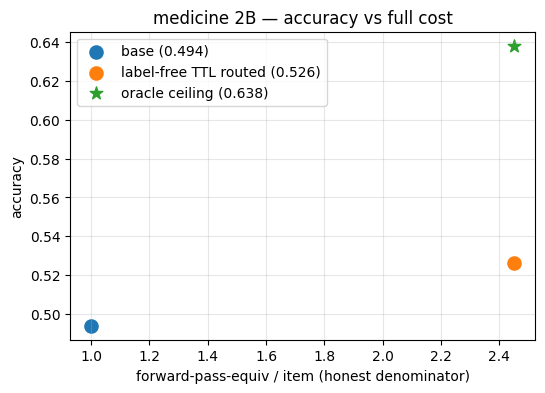

In [19]:
frac=0.05  # top-5% trained (CE-split recipe)
stages={"confidence signal":1, "pseudo-label gen (k*frac)":K_SAMPLES*frac,
        "adapter train (frac)":frac, "routed inference":1}
cost_lf=sum(stages.values()); cost_base=1
print("forward-pass-equivalents / item:")
for k,v in stages.items(): print(f"  {k:28s} {v:.2f}")
print(f"  {'TOTAL label-free TTL':28s} {cost_lf:.2f}   ({cost_lf/cost_base:.1f}x base)")
# accuracy-per-cost on medicine 2b (best real TTL cell), label-free routed (mc_top_p) vs base vs oracle
sub=with_gpu(cell("medicine","2b","random5"),"medicine")
lf_acc=best_routed(sub,"mc_top_p",ORIENT["mc_top_p"])[0]; base_acc=sub.base_ok.mean(); orc=(sub.base_ok|sub.adapted_ok).mean()
import matplotlib.pyplot as plt
fig,ax=plt.subplots(figsize=(6,4))
ax.scatter([cost_base],[base_acc],s=90,label=f"base ({base_acc:.3f})")
ax.scatter([cost_lf],[lf_acc],s=90,label=f"label-free TTL routed ({lf_acc:.3f})")
ax.scatter([cost_lf],[orc],s=90,marker="*",label=f"oracle ceiling ({orc:.3f})")
ax.set_xlabel("forward-pass-equiv / item (honest denominator)"); ax.set_ylabel("accuracy")
ax.set_title("medicine 2B — accuracy vs full cost"); ax.legend(); ax.grid(alpha=.3); plt.show()
gain_per_x=(lf_acc-base_acc)/(cost_lf-cost_base)
record("D6 cost honesty", "acc gain per extra fwd-equiv (medicine 2B)", round(gain_per_x,4),
       "DOMINATES" if lf_acc>base_acc and gain_per_x>0.01 else "MARGINAL",
       f"label-free routed {lf_acc:.3f} vs base {base_acc:.3f} at {cost_lf:.1f}x cost")

## D7 · Unification tension — do selection & routing fail together?

We proposed collapsing selection and routing onto one uncertainty signal (elegant, answers the
'post-hoc framework' critique). But a single signal makes their failures perfectly correlated —
a domain where it's miscalibrated fails at both stages with nothing to catch it. We measure the
pairwise correlation of candidate signals; low correlation between two label-free signals is the
robustness you'd forfeit by unifying.

In [20]:
sub=with_gpu(cell("medicine","2b","random5"),"medicine")
sigs=[s for s in ["mc_top_p","q_ce","out_ce","cmp","within"] if s in sub and not sub[s].isna().all()]
Z=sub[sigs].astype(float)
corr=Z.corr().round(3); display(corr)
# correlated-failure: if we unify on mc_top_p for BOTH select+route, both are wrong on the same items.
# decorrelated alt: mc_top_p (route) + q_ce (select). Measure overlap of their 'wrong-half' calls.
def wrong_half(sig):
    s=ORIENT[sig]*sub[sig].values.astype(float); return s>=np.nanmedian(s)
if "q_ce" in sigs:
    a=wrong_half("mc_top_p"); b=wrong_half("q_ce")
    jaccard=(a&b).sum()/max(1,(a|b).sum())
    record("D7 unification", "wrong-half overlap mc_top_p vs q_ce", round(float(jaccard),3),
           "DECORRELATED (keep both)" if jaccard<0.4 else "REDUNDANT (unify safely)",
           "low overlap => a 2nd independent signal buys error-correction the unified design loses")
    print(f"\nwrong-half Jaccard(mc_top_p, q_ce) = {jaccard:.3f}  (low => unifying forfeits real diversity)")

,mc_top_p,q_ce,out_ce,cmp,within
mc_top_p,1.000,0.005,-0.052,-0.052,0.072
q_ce,0.005,1.000,-0.046,-0.071,0.008
out_ce,-0.052,-0.046,1.000,0.086,-0.116
cmp,-0.052,-0.071,0.086,1.000,0.122
within,0.072,0.008,-0.116,0.122,1.000



wrong-half Jaccard(mc_top_p, q_ce) = 0.357  (low => unifying forfeits real diversity)


## D8 · Offline vs online routing — streaming-quantile error

The rank-based recipe needs the whole stream to set the percentile; deployment sees items one at
a time. We compare offline global-quantile routing to an online running-quantile estimate over
the item stream and report the accuracy delta.

In [21]:
def offon(sub, sig, Y=0.30):
    s=ORIENT[sig]*sub[sig].values.astype(float); b=sub.base_ok.values; a=sub.adapted_ok.values
    # route the LOW-signal (base-likely-right) fraction to base -> here 'to base' = signal small
    val=sub[sig].values.astype(float) if ORIENT[sig]>0 else -sub[sig].values.astype(float)
    thr=np.quantile(val,Y); off_route=val<=thr; off=np.mean(np.where(off_route,b,a))
    seen=[]; on_route=[]
    for i in range(len(val)):
        seen.append(val[i]); t=np.quantile(seen,Y) if len(seen)>=10 else -np.inf
        on_route.append(val[i]<=t)
    on_route=np.array(on_route); on=np.mean(np.where(on_route,b,a))
    return off,on,off_route.mean(),on_route.mean()
rows=[]
for ds,model,pool in [("medicine","2b","random5"),("medicine","0.8b","random5"),("logiqa","0.8b","random")]:
    sub=cell(ds,model,pool)
    if len(sub)==0: continue
    for sig in ["out_ce","mc_top_p"]:
        if sig not in sub or sub[sig].isna().all(): continue
        off,on,fo,fn=offon(sub,sig)
        rows.append((f"{ds}/{model}",sig,round(off,3),round(on,3),round((on-off)*100,1)))
D8=pd.DataFrame(rows, columns=["cell","signal","offline","online","delta_pp"]); display(D8)
worst=D8.delta_pp.abs().max()
record("D8 online routing", "worst |offline-online| routed-acc", float(round(worst,1)),
       "NEGLIGIBLE" if worst<0.5 else ("SMALL" if worst<1.5 else "MATTERS"),
       "streaming-quantile cost of one-item-at-a-time deployment")

,cell,signal,offline,online,delta_pp
0,medicine/2b,out_ce,0.548,0.547,-0.1
1,medicine/2b,mc_top_p,0.521,0.522,0.1
2,medicine/0.8b,out_ce,0.474,0.470,-0.4
3,medicine/0.8b,mc_top_p,0.374,0.374,0.0
4,logiqa/0.8b,out_ce,0.441,0.440,-0.1


## D9 · Contamination check (procedure, not a number)

The eval pivot's validity depends on the "shifted" bench being genuinely novel — apparent
headroom can be a weaker checkpoint memorising less, not real shift. This can't be computed from
committed artifacts; it's a gate to run when you pick the shifted domains:

1. **n-gram / substring overlap** of each test item against a pretraining-corpus proxy
   (e.g. C4 / RedPajama sample). Flag items with high 13-gram overlap.
2. **Date-holdout**: prefer benches published after the base model's cutoff; report the
   pre/post-cutoff accuracy split — a large gap is a contamination smell.
3. **Perturbation test**: paraphrase / renumber answer options; genuine capability is
   perturbation-stable, memorisation is not.
4. **Report the contaminated-subset-excluded headroom** as the headline, not the raw number.

Until this passes on a chosen shifted bench, D1 headroom on that bench is provisional.

In [22]:
record("D9 contamination", "procedure gate", "manual", "TODO",
       "run n-gram overlap + date-holdout + perturbation before trusting shifted-bench headroom")
print("D9 is a manual gate — recorded as TODO in the scorecard.")

D9 is a manual gate — recorded as TODO in the scorecard.


## D10 · Distribution-shift pivot — does the label-free signal wake up OOD? *(opt-in GPU)*

The only place the label-free story can revive: not a new signal, but a regime where the existing
signals stop being blind. A base model that's genuinely out of distribution is often
*well-calibrated about being lost* — so within-model confidence may separate right from wrong far
better OOD than in-distribution (where it stalled at ~0.69). This cell points at a shifted bench,
computes headroom (D1-style) and within-model AUROC (D2-style) on it, and asks the one question:
**does within-AUROC rise vs the in-distribution value?**

Set `SHIFT_DATASET` to a genuinely-novel bench (contamination-gate it first — D9). It trains a
top-CE specialist on the shift set, generates base+adapted+within, grades, and compares.

In [23]:
SHIFT_DATASET   = None    # e.g. "data/AdaptEval/<novel_bench>.json"  (must pass the D9 contamination gate)
SHIFT_TAG       = "shift"
SHIFT_N         = 500

if RUN_GPU and SHIFT_DATASET:
    import torch, torch.nn.functional as F
    from pathlib import Path
    sys.path.insert(0, str(SCRIPTS)); import grading
    at=grading.detect_answer_type(SHIFT_TAG) if SHIFT_TAG in ("choice","numeric") else "choice"
    W=Path(WORK)/"saves_stress"/SHIFT_TAG; W.mkdir(parents=True, exist_ok=True)
    recs_s=json.load(open(SHIFT_DATASET))[:SHIFT_N]
    # features (out_ce) via the repo pool builder, then top-CE specialist
    if not (W/"pool"/"features.jsonl").exists():
        sh([sys.executable,str(SCRIPTS/"ab_build_pool.py"),"--model",MODEL,"--data",SHIFT_DATASET,
            "--dataset",SHIFT_TAG,"--max-samples",str(SHIFT_N),"--out-dir",str(W/"pool")], W/"pool.log")
    feats=[json.loads(l) for l in open(W/"pool"/"features.jsonl")]; oce={f["idx"]:f["out_ce"] for f in feats}
    cap=max(1,int(0.05*len(feats))); sel=sorted(oce,key=lambda i:-oce[i])[:cap]
    json.dump({"selected":[{"idx":int(i),"weight":1.0} for i in sel]}, open(W/"sel.json","w"))
    if not (W/"adapter"/"adapter_model.safetensors").exists():
        sh([sys.executable,str(SCRIPTS/"ab_train_ttl.py"),"--model",MODEL,"--data",SHIFT_DATASET,
            "--selection-file",str(W/"sel.json"),"--max-samples",str(SHIFT_N),"--output-dir",str(W/"adapter"),"--no-merge"], W/"train.log")
    def grade_ok(path):
        ok={}
        for ln in open(path):
            r=json.loads(ln); ex=grading.extract(str(r.get("predict","")),at); ok[int(r["idx"])]=bool(grading.is_correct(ex.value,str(r["label"]),at))
        return ok
    hf_generate(MODEL, SHIFT_DATASET, W/"preds_base.jsonl", SHIFT_N)
    hf_generate(str(W/"adapter"), SHIFT_DATASET, W/"preds_adapted.jsonl", SHIFT_N)
    base_ok=grade_ok(W/"preds_base.jsonl"); adp_ok=grade_ok(W/"preds_adapted.jsonl")
    # within-model confidence on the shift set
    within={}; bm,btok=load_lm(MODEL)
    for s in range(0,len(recs_s),(GEN_BATCH if "GEN_BATCH" in globals() else 8)):
        ch=list(range(s,min(s+(GEN_BATCH if "GEN_BATCH" in globals() else 8),len(recs_s))))
        enc=btok([wrap(btok,(recs_s[i].get("question") or recs_s[i].get("instruction","")).strip()) for i in ch],
                 return_tensors="pt",padding=True,truncation=True,max_length=2048).to(bm.device)
        w=enc["input_ids"].shape[1]
        with torch.inference_mode():
            o=bm.generate(**enc,max_new_tokens=64,do_sample=False,output_scores=True,return_dict_in_generate=True,pad_token_id=btok.pad_token_id)
        seq=o.sequences[:,w:]; P=torch.stack([torch.softmax(sc.float(),-1) for sc in o.scores],1)
        ch_p=P.gather(-1,seq.unsqueeze(-1)).squeeze(-1); mk=(seq!=btok.pad_token_id)
        for bi,i in enumerate(ch): within[i]=float(ch_p[bi][mk[bi]].mean()) if mk[bi].any() else 0.0
    del bm; torch.cuda.empty_cache()
    common=[i for i in base_ok if i in adp_ok and i in within]
    b=np.mean([base_ok[i] for i in common]); a=np.mean([adp_ok[i] for i in common])
    orc=np.mean([base_ok[i] or adp_ok[i] for i in common]); head=orc-b
    yw=[0 if base_ok[i] else 1 for i in common]; within_auroc=auroc(yw,[-within[i] for i in common])
    # in-distribution reference: best within AUROC we measured (medicine 2B ~0.686 unless recomputed)
    id_ref=0.686
    print(f"SHIFT [{SHIFT_DATASET}]  base={b:.3f} adapt_all={a:.3f} oracle={orc:.3f} headroom={head:+.3f}")
    print(f"within-model AUROC  shift={within_auroc:.3f}  vs in-distribution~{id_ref:.3f}  -> delta {within_auroc-id_ref:+.3f}")
    v = "SIGNAL WAKES UP OOD" if within_auroc-id_ref>=0.05 and head>=0.10 else ("STILL BLIND OOD" if within_auroc<0.62 else "MIXED")
    record("D10 shift pivot", "within-AUROC shift vs in-dist", round(float(within_auroc),3), v,
           f"headroom={head:+.3f}; the positive case lives here or nowhere")
else:
    print("shift pivot off — set SHIFT_DATASET to a contamination-clean OOD bench (D9) and RUN_GPU=True.")
    print("This is the one experiment that can revive the label-free router; everything above is in-distribution.")

shift pivot off — set SHIFT_DATASET to a contamination-clean OOD bench (D9) and RUN_GPU=True.
This is the one experiment that can revive the label-free router; everything above is in-distribution.


## 6 · Consolidated scorecard — distance from the full idea

Each diagnostic contributes one or more rows. Read the `verdict` column top-to-bottom: it's the
honest status of every claim the label-free TTL pipeline needs to be true.

In [24]:
SC=pd.DataFrame(SCORECARD)
pd.set_option("display.max_colwidth", 60)
display(SC)

print("\n=================  DISTANCE FROM THE FULL IDEA  =================\n")
def has(issue, kw):
    return any((issue in r["issue"]) and (kw in str(r["verdict"])) for r in SCORECARD)

# the load-bearing gap: label-free router AUROC vs the out_ce ceiling
d2=[r for r in SCORECARD if "label-free router" in r["issue"]]
if d2:
    best=max(r["value"] for r in d2 if isinstance(r["value"],(int,float)))
    print(f"• LABELLING (the critical path): best deployable router AUROC ≈ {best:.2f}.")
    print("  out_ce (gold-leaking) sits ~0.92–0.99. That spread IS the gap you must close before")
    print("  the exploitation claim is deployable. If CMP (GPU arm) didn't clear ~0.70, the paper")
    print("  stays the phenomenon, stated honestly.\n")
print("• HEADROOM: geography ~dead, medicine live — so a per-domain 'don't-adapt' gate is required,")
print("  and the eval pivot must target live-headroom domains (D1).")
print("• VERIFIER: saturates into the votes by 4B (D4) — the self-distillation target's quality")
print("  ceiling under shift depends on this; it's the recursion (need a calibrated verifier on the")
print("  new domain to be label-free on the new domain).")
print("• FORGETTING: the specialist breaks a large fraction of base-correct items (D5) — anchoring")
print("  is the adapter-alteration lever to test next.")
print("• COST: label-free TTL runs ~{:.1f}x base compute (D6); the Pareto must clear that.".format(
      sum({ "c":1,"p":K_SAMPLES*0.05,"t":0.05,"i":1 }.values())))
print("• ROUTING is offline≈online here (D8) and the label-free signals are decorrelated (D7),")
print("  so keep two signals rather than unifying to one.\n")
print("Next action is set by D2: if a label-free signal clears ~0.70 on the shifted bench, build the")
print("verified-self-distillation loop; if not, retreat to the small-labelled-dev-set framing and")
print("report the label-free-vs-oracle gap as the headline result.")

,issue,metric,value,verdict,note
0,D1 headroom,oracle-base [geography],0.058,THIN,adapt-all helps unrouted (+0.027)
1,D1 headroom,oracle-base [logiqa],0.091,THIN,adapt-all helps unrouted (+0.022)
2,D1 headroom,oracle-base [medicine],0.224,LIVE,adapt-all helps unrouted (+0.077)
3,D2 label-free router,best label-free AUROC [logiqa/0.8b],0.666,MARGINAL,vs out_ce(leak) 0.989 — deployability gap +0.323
4,D2 label-free router,best label-free AUROC [medicine/0.8b],0.68,MARGINAL,vs out_ce(leak) 0.928 — deployability gap +0.248
5,D2 label-free router,best label-free AUROC [medicine/2b],0.686,MARGINAL,vs out_ce(leak) 0.99 — deployability gap +0.304
6,D2 label-free router,best label-free AUROC [geography/0.8b],0.755,ROUTER EXISTS,vs out_ce(leak) 0.988 — deployability gap +0.233
7,D2b CMP debug,cmp best-orient / conf-wrong [logiqa/0.8b],0.629,CMP BLIND,"len-conf corr=0.01, cmp@cw=0.616, within@cw=0.651"
8,D2b CMP debug,cmp best-orient / conf-wrong [medicine/0.8b],0.578,CMP HELPS @conf-wrong,"len-conf corr=-0.361, cmp@cw=0.676, within@cw=0.598"
9,D2b CMP debug,cmp best-orient / conf-wrong [medicine/2b],0.52,CMP BLIND,"len-conf corr=-0.361, cmp@cw=0.615, within@cw=0.539"



=================  DISTANCE FROM THE FULL IDEA  =================

• LABELLING (the critical path): best deployable router AUROC ≈ 0.76.
  out_ce (gold-leaking) sits ~0.92–0.99. That spread IS the gap you must close before
  the exploitation claim is deployable. If CMP (GPU arm) didn't clear ~0.70, the paper
  stays the phenomenon, stated honestly.

• HEADROOM: geography ~dead, medicine live — so a per-domain 'don't-adapt' gate is required,
  and the eval pivot must target live-headroom domains (D1).
• VERIFIER: saturates into the votes by 4B (D4) — the self-distillation target's quality
  ceiling under shift depends on this; it's the recursion (need a calibrated verifier on the
  new domain to be label-free on the new domain).
• FORGETTING: the specialist breaks a large fraction of base-correct items (D5) — anchoring
  is the adapter-alteration lever to test next.
• COST: label-free TTL runs ~2.5x base compute (D6); the Pareto must clear that.
• ROUTING is offline≈online here (D8) an

## 7 · Comparison vs the previous run

The previous session's D2 (pre-fix CMP: re-tokenised span; below-chance). This cell pins those
numbers and diffs them against the current run so the effect of the span fix + debug is explicit.
If the GPU arm didn't run this session, the current CMP/within columns are `NaN` and the table
just shows the frozen previous values as the reference to beat.

In [25]:
# frozen previous-run D2 (the table you pasted)
PREV = pd.DataFrame([
    dict(dataset="logiqa",   model="0.8b", out_ce=0.989, q_ce=0.500, cmp_prev=0.505, within_prev=0.666),
    dict(dataset="medicine", model="0.8b", out_ce=0.928, q_ce=0.496, cmp_prev=0.446, within_prev=0.680),
    dict(dataset="medicine", model="2b",   out_ce=0.990, q_ce=0.486, cmp_prev=0.478, within_prev=0.574),
    dict(dataset="geography",model="0.8b", out_ce=0.988, q_ce=0.513, cmp_prev=0.447, within_prev=0.755),
])
# current CMP/within from this run's GPU cache (NaN if the arm didn't run)
cur=[]
for _,p in PREV.iterrows():
    ds,m=p.dataset,p.model
    cmp_now=within_now=np.nan
    if GPU.get("cmp",{}).get(ds):
        sub=with_gpu(cell(ds,m,df[(df.dataset==ds)&(df.model==m)].pool.iloc[0]) if len(df[(df.dataset==ds)&(df.model==m)]) else pd.DataFrame(), ds)
        if len(sub) and "cmp" in sub and not sub["cmp"].isna().all():
            yw=(~sub.base_ok).astype(int).values
            cmp_now=round(auroc(yw, sub["cmp"].values.astype(float)),3)
            within_now=round(auroc(yw, -sub["within"].values.astype(float)),3) if not sub["within"].isna().all() else np.nan
    cur.append(dict(dataset=ds, model=m, cmp_now=cmp_now, within_now=within_now))
CUR=pd.DataFrame(cur)
COMP=PREV.merge(CUR, on=["dataset","model"])
COMP["cmp_delta"]=(COMP["cmp_now"]-COMP["cmp_prev"]).round(3)
COMP["within_delta"]=(COMP["within_now"]-COMP["within_prev"]).round(3)
display(COMP[["dataset","model","out_ce","cmp_prev","cmp_now","cmp_delta","within_prev","within_now","within_delta"]])

if COMP["cmp_now"].isna().all():
    print("\nGPU arm not run this session — showing frozen previous CMP/within as the reference.")
    print("Rerun §4b (RUN_GPU_ARMS=True) to fill cmp_now with the fixed-span computation, then re-run this cell.")
else:
    moved=COMP["cmp_delta"].abs().max()
    print(f"\nLargest CMP shift from the span fix: {moved:+.3f}.")
    print("If cmp_now jumped above ~0.62 (esp. on medicine 2B) the earlier 'CMP blind' verdict was a span bug.")
    print("If cmp_now is still ~0.5 with the fixed span, the negative is now clean and earned — check D2b's")
    print("confident-wrong column before writing it down.")

,dataset,model,out_ce,cmp_prev,cmp_now,cmp_delta,within_prev,within_now,within_delta
0,logiqa,0.8b,0.989,0.505,0.629,0.124,0.666,0.666,0.0
1,medicine,0.8b,0.928,0.446,0.578,0.132,0.680,0.680,0.0
2,medicine,2b,0.990,0.478,0.520,0.042,0.574,0.574,0.0
3,geography,0.8b,0.988,0.447,0.745,0.298,0.755,0.755,0.0



Largest CMP shift from the span fix: +0.298.
If cmp_now jumped above ~0.62 (esp. on medicine 2B) the earlier 'CMP blind' verdict was a span bug.
If cmp_now is still ~0.5 with the fixed span, the negative is now clean and earned — check D2b's
confident-wrong column before writing it down.
